# Pipeline de Deep Learning para Detección de Vishing
Este notebook implementa arquitecturas de Deep Learning profundo usando TensorFlow/Keras para evaluar el rendimiento sobre los datasets previamente balanceados. Compararemos Redes Densas estándar y Redes Convolucionales 1D adaptadas para datos tabulares.

## 1. Setup y Preparación de Datos (Hold-out Test Set)

In [2]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Conv1D, GlobalMaxPooling1D, Reshape
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargar datos originales para obtener un Test Set realista y consistente con el pipeline ML
df_raw = pd.read_csv('raw_data/dataset_sintetico_biocatch_vishing.csv')

# Excluir features que causan data leakage según el EDA
cols_to_drop = ['session_id', 'customer_id', 'session_timestamp', 'biocatch_risk_score', 'biocatch_genuine_score', 
                'biocatch_ato_indicator', 'biocatch_social_eng_indicator', 'biocatch_bot_indicator', 'days_to_claim', 
                'claim_category', 'os_type', 'app_version', 'device_type']

for col in ['screens_visited', 'unusual_screen_visits']:
    if col in df_raw.columns:
        df_raw.drop(columns=[col], inplace=True)

df_raw = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])

X_orig = df_raw.drop(columns=['is_vishing'])
y_orig = df_raw['is_vishing']

_, X_test, _, y_test = train_test_split(X_orig, y_orig, test_size=0.20, random_state=42, stratify=y_orig)

scaler = StandardScaler()
input_dim = X_test.shape[1]
print(f"Dimensiones de entrada: {input_dim}")

Dimensiones de entrada: 45


## 2. Definición de Arquitecturas Deep Learning
Definimos funciones para construir los modelos dinámicamente según la dimensión de entrada.

In [4]:
def build_dnn(input_dim):
    """Red Neuronal Densa Estándar con Regularización (Dropout y BatchNorm)"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC', 'Precision', 'Recall'])
    return model

def build_cnn1d(input_dim):
    """Red Neuronal Convolucional 1D adaptada para extraer patrones locales tabulares"""
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)), # Convertimos el vector 1D tabular a formato secuencial para Conv1D
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC', 'Precision', 'Recall'])
    return model

## 3. Pipeline de Entrenamiento y Evaluación
Iteramos sobre todos los datasets balanceados al igual que en el pipeline de Machine Learning.

In [5]:
data_paths = glob.glob('data/**/*.csv', recursive=True)
results = []

early_stopping = EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)

print(f"Detectados {len(data_paths)} datasets balanceados para evaluación DL.")

for path in data_paths:
    technique = Path(path).parent.name
    ratio = Path(path).stem
    
    print(f"\n--- Evaluando DL: {technique} al {ratio}% ---")
    
    df_train = pd.read_csv(path)
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], errors='ignore')
    for col in ['screens_visited', 'unusual_screen_visits']:
        if col in df_train.columns:
            df_train.drop(columns=[col], inplace=True)
            
    X_train = df_train.drop(columns=['is_vishing'])
    y_train = df_train['is_vishing']
    
    X_train = X_train[X_test.columns]
    
    # Es vital escalar para Deep Learning
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Definir modelos para esta iteración
    models = {
        'DNN_Dropout': build_dnn(input_dim),
        'CNN_1D': build_cnn1d(input_dim)
    }
    
    for model_name, model in models.items():
        print(f"  Entrenando {model_name}...")
        # Entrenamos reservando 10% del train para validation (early stopping)
        model.fit(X_train_scaled, y_train, epochs=30, batch_size=64, 
                  validation_split=0.1, callbacks=[early_stopping], verbose=0)
        
        y_prob = model.predict(X_test_scaled).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        
        results.append({
            'Technique': technique,
            'Ratio_%': ratio,
            'Model': model_name,
            'Recall': recall,
            'Precision': precision,
            'F1': f1,
            'ROC_AUC': roc_auc,
            'PR_AUC': pr_auc
        })

print("\n¡Pipeline Deep Learning finalizado!")

Detectados 12 datasets balanceados para evaluación DL.

--- Evaluando DL: borderline_smote al 10% ---
  Entrenando DNN_Dropout...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
  Entrenando CNN_1D...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

--- Evaluando DL: borderline_smote al 20% ---
  Entrenando DNN_Dropout...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Entrenando CNN_1D...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- Evaluando DL: borderline_smote al 25% ---
  Entrenando DNN_Dropout...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Entrenando CNN_1D...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluando DL: random_oversampling al 10% ---
  Entrenando DNN_Dropout...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
  Entrenando CNN_1D...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluando DL: random_oversampling al 20% ---
  Entrenando DNN_Dropout...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Entrenando CNN_1D...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluando DL: random_oversamplin

## 4. Análisis de Resultados e Identificación del Mejor Modelo

In [6]:
df_results_dl = pd.DataFrame(results)

df_results_dl_sorted = df_results_dl.sort_values(by='PR_AUC', ascending=False)
display(df_results_dl_sorted.head(10).style.background_gradient(cmap='magma', subset=['Recall', 'PR_AUC', 'ROC_AUC']))

,Technique,Ratio_%,Model,Recall,Precision,F1,ROC_AUC,PR_AUC
13,smote,10,CNN_1D,0.682000,0.406436,0.509335,0.806917,0.679876
1,borderline_smote,10,CNN_1D,0.480000,0.458891,0.469208,0.570946,0.498643
10,random_oversampling,25,DNN_Dropout,0.884000,0.162023,0.273854,0.895196,0.451089
21,smote_undersampling,20,CNN_1D,1.000000,0.081327,0.150421,0.966909,0.445260
0,borderline_smote,10,DNN_Dropout,0.302000,0.722488,0.425952,0.489831,0.349654
17,smote,25,CNN_1D,0.990000,0.163745,0.281011,0.939211,0.312096
4,borderline_smote,25,DNN_Dropout,0.846000,0.346154,0.491289,0.846934,0.306069
20,smote_undersampling,20,DNN_Dropout,0.838000,0.350628,0.494395,0.832739,0.302588
16,smote,25,DNN_Dropout,0.836000,0.325292,0.468347,0.820046,0.296127
9,random_oversampling,20,CNN_1D,0.272000,0.386364,0.319249,0.299091,0.280197


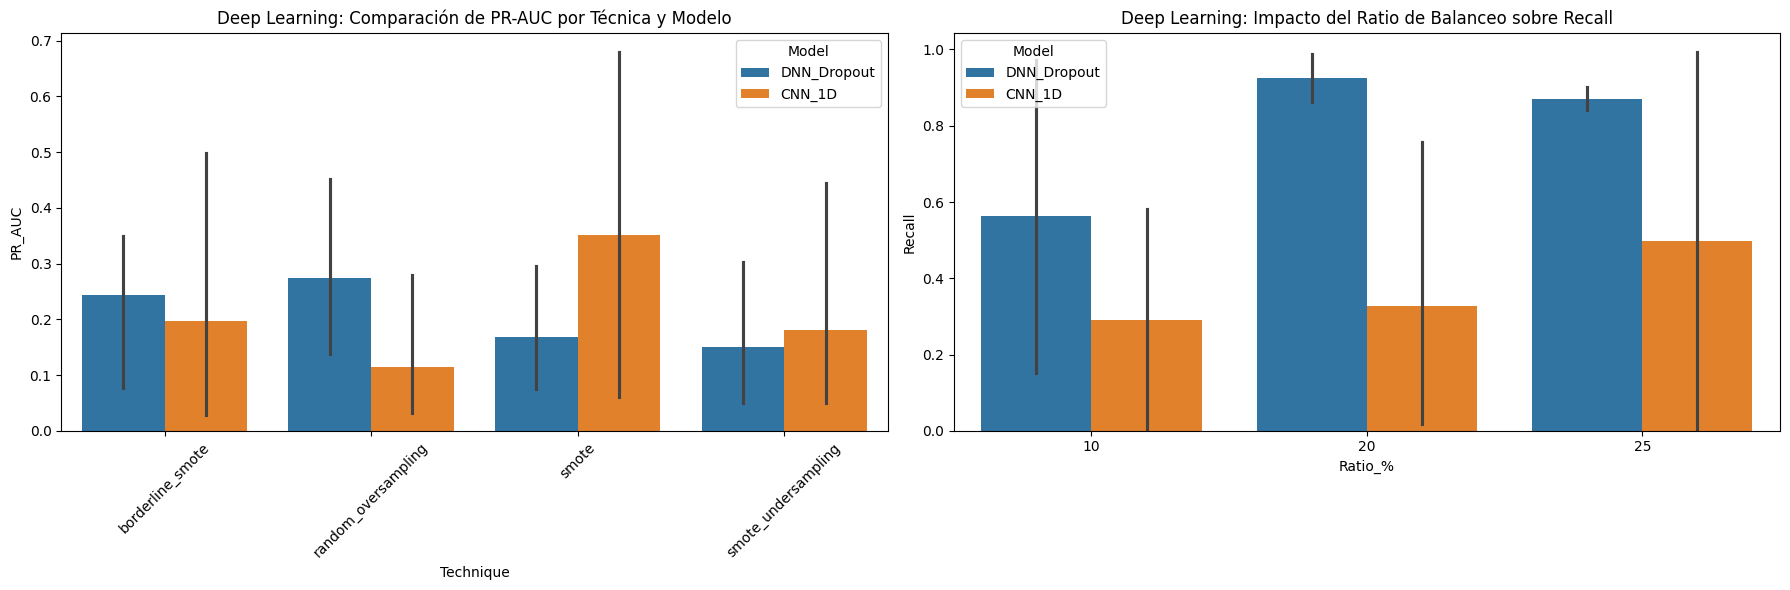

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_results_dl, x='Technique', y='PR_AUC', hue='Model', ax=ax1)
ax1.set_title('Deep Learning: Comparación de PR-AUC por Técnica y Modelo')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sns.barplot(data=df_results_dl, x='Ratio_%', y='Recall', hue='Model', ax=ax2)
ax2.set_title('Deep Learning: Impacto del Ratio de Balanceo sobre Recall')

plt.tight_layout()
plt.show()